In [1]:
import os
import sys
sys.path.append('../.')
from utils.utils import save_image_grid_with_labels, get_concept_index
import argparse
import numpy as np
from pathlib import Path
import yaml
import torch
from ast import literal_eval
from torch.autograd import Variable
from torchvision.utils import save_image, make_grid
import torch.nn.functional as F
from torch.nn.functional import softmax, one_hot
from torch import nn
from models import cbae_stygan2, clip_pseudolabeler
from torchvision import transforms, models
from utils import gan_loss
from utils.utils import get_concept_index
import itertools
import warnings
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from eval.eval_intervention_gan import opt_int
import time

%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # Higher resolution figures

### Setup


In [2]:
# dataset to evaluate on
dataset = 'celebahq'
# experiment name
expt_name = 'cbae_stygan2_thr90'
# tensorboard name
tensorboard_name = 'sup_pl_random_concepts'  # CHANGED
# whether to use optimization-based interventions
optint = True
optint_eps = 0.1
optint_iters = 50

clsf_model_type = 'rn18'
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

### Load generative model with CB-AE

In [3]:
config_file = f"../config/{expt_name}/"+dataset+".yaml"

with open(config_file, 'r') as stream:
    config = yaml.safe_load(stream)
print(f"Loaded configuration file {config_file}")

Loaded configuration file ../config/cbae_stygan2_thr90/celebahq.yaml


In [4]:
num_cls = 8
set_of_classes = [  # RANDOM CONCEPTS
    ['Class 0A', 'Class 0B'],
    ['Class 1A', 'Class 1B'],
    ['Class 2A', 'Class 2B'],
    ['Class 3A', 'Class 3B'],
    ['Class 4A', 'Class 4B'],
    ['Class 5A', 'Class 5B'],
    ['Class 6A', 'Class 6B'],
    ['Class 7A', 'Class 7B']
]

conc_clsf_classes = [
    'Class 0',
    'Class 1',
    'Class 2',
    'Class 3',
    'Class 4',
    'Class 5',
    'Class 6',
    'Class 7'
]

config['model']['pretrained'] = '../models/checkpoints/stylegan2-celebahq-256x256.pkl'
model = cbae_stygan2.cbAE_StyGAN2(config)

cbae_ckpt_path = f'../models/checkpoints/{dataset}_{expt_name}_{tensorboard_name}_cbae.pt'

model.cbae.load_state_dict(torch.load(cbae_ckpt_path, map_location='cpu'))
model.to(device)
model.eval();

loading stylegan2 from ../models/checkpoints/stylegan2-celebahq-256x256.pkl
Total concepts (including unknown): 56
number of layers in CB-AE: 20


### Load concept classifier to evaluate concept interventions

In [5]:
clip_zs = clip_pseudolabeler.CLIP_PseudoLabeler(set_of_classes, device)

### Intervention Helpers

In [6]:
def classify_images_all_concepts(imgs):
    num_images = imgs.size(0)
    result = [dict() for _ in range(num_images)]
    all_logits = clip_zs.get_soft_pseudo_labels(imgs)

    for conc_labels, conc, logits in zip(
        set_of_classes, conc_clsf_classes, all_logits
    ):
        prob = softmax(logits, dim=1)  # [num_images, 2]
        pred = prob.argmax(dim=1)
        for i in range(num_images):
            label = conc_labels[pred[i].item()]
            confidence = prob[i][pred[i].item()].item()
            result[i][conc] = (label, confidence)

    return result

In [7]:
def generate_confident_images(model, target_concept, concept_value, batch_size=32, num_images=10, threshold=0.9):
    idx = conc_clsf_classes.index(target_concept)
    target_label = set_of_classes[idx][1 - concept_value]

    confident_images = []
    confident_latents = []
    confident_preds = []
    attempts = 0
    while len(confident_images) < num_images:
        # generate batch
        z_batch = torch.randn((batch_size, model.gen.z_dim), device=device)
        w_batch = model.gen.mapping(z_batch, None, truncation_psi=1.0)
        x_batch = model.cbae.dec(model.cbae.enc(w_batch))
        img_batch = model.gen.synthesis(x_batch, noise_mode='const').clamp(-1, 1).mul(0.5).add_(0.5)

        # Classify all concepts
        batch_preds = classify_images_all_concepts(img_batch)

        for i in range(img_batch.size(0)):
            label, confidence = batch_preds[i][target_concept]
            if label == target_label and confidence > threshold:
                confident_images.append(img_batch[i].unsqueeze(0))
                confident_latents.append(w_batch[i].unsqueeze(0))
                confident_preds.append(batch_preds[i])
            if len(confident_images) >= num_images:
                break
        
        # clear cache
        del z_batch, w_batch, x_batch, img_batch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        attempts += 1
        
        # give up
        if attempts >= 15:
            raise RuntimeError(f"Unable to find confident images with {target_concept}: {concept_value}")

    images = torch.cat(confident_images[:num_images], dim=0)
    latents = torch.cat(confident_latents[:num_images], dim=0)
    preds = confident_preds[:num_images]
    return images, latents, preds

In [8]:
def swap_intervention(model, latent, start, end):
    """
    Perform binary concept logit swap
    """
    original_concept = model.cbae.enc(latent)
    
    swapped_concept = original_concept.clone()
    temp = swapped_concept[:, start].clone()
    swapped_concept[:, start] = swapped_concept[:, end-1]
    swapped_concept[:, end-1] = temp

    return model.cbae.dec(swapped_concept)

### Visualization / Quantification Helpers

In [9]:
def show_all_class_results(result, target_concept, original_result):
    max_len = max(map(len, result)) + 2

    # format string
    orig_lbl_t = original_result[target_concept][0]
    lbl_t, conf_t = result[target_concept]
    success = orig_lbl_t != lbl_t
    
    line = f"[Target] {'*' if success else ''}{lbl_t}: {conf_t:.1%}"
    line = line + '\n' + len(line) * '-'

    for conc, (lbl, conf) in result.items():
        orig_lbl = original_result[conc][0]
        if conc != target_concept:
            if lbl == orig_lbl:
                line += f'\n{lbl:>{max_len}}: {conf:.1%}'
            else:
                disp_lbl = '*' + lbl
                line += f'\n{disp_lbl:>{max_len}}: {conf:.1%}'

    return line, success

In [10]:
def visualize_intervention(images, results, types, target_concept, all_concepts=False):
    num_samples = len(images[0])
    num_images = len(images)
    intervention_counts = {t: 0 for t in types if t.lower() != 'original'}
    
    for i in range(num_samples):
        sample_images = [imgs[i] for imgs in images]
        sample_results = [preds[i] for preds in results]
        orig_pred = sample_results[0]

        fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
        for ax, im, r, t in zip(axes, sample_images, sample_results, types):
            # process information
            r_text, success = show_all_class_results(r, target_concept, orig_pred)
            if t.lower() != 'original':
                intervention_counts[t] += success
            
            if all_concepts:
                r_text, success = show_all_class_results(r, target_concept, orig_pred)
                success_text = 'Success' if success else 'Fail'
                title = f'{t} ({r[target_concept][0]})' if t == 'Original' else f'{t} ({success_text})'
            else:
                img_concept, img_conf = r[target_concept]
                orig_concept = orig_pred[target_concept][0]
                img_label = '*' * (img_concept != orig_concept) + img_concept
                title = f'{t} ({img_label}, {img_conf:.1%})'
            
            # plot
            ax.imshow(im.detach().cpu().permute(1, 2, 0).numpy())
            ax.set_title(title)
            ax.axis('off')
            
            if all_concepts:
                ax.text(
                    0.5, -0.05, r_text,
                    transform=ax.transAxes, ha='center', va='top', 
                    family='monospace', fontsize=9
                )
        plt.tight_layout()
        plt.show()
    
    # intervention stats
    print("Total Intervention Success Rates:")
    for t, count in intervention_counts.items():
        print(f"{t}: {count / num_samples:.2%}")

### Intervention Visualization

* Select target concept from: Class 0-7
* Use `concept_value=1` for intervention target to be target concept (e.g. Smiling) and `concept_value=0` for opposite of target concept (e.g. Not Smiling).

In [11]:
def entanglement_examples(target_concept, concept_value, num_samples, threshold=0.9):
    concept_change = conc_clsf_classes.index(target_concept)
    start, end = get_concept_index(model, concept_change)

    # generate images
    orig_imgs, orig_latent, orig_preds = generate_confident_images(
        model, target_concept, concept_value, num_images=num_samples,
        threshold=threshold
    )

    # CB-AE bottleneck swap
    swap_latent = swap_intervention(model, orig_latent.clone(), start, end)
    swap_imgs = model.gen.synthesis(
       swap_latent, noise_mode='const'
    ).clamp(-1,1).mul(0.5).add_(0.5)
    swap_preds = classify_images_all_concepts(swap_imgs)

    # PGD optimization-based intervention
    pgd_latent = opt_int(
        model, orig_latent, concept_change, concept_value,
        num_iters=optint_iters, eps=optint_eps, device=device 
    )
    pgd_imgs = model.gen.synthesis(
       pgd_latent, noise_mode='const'
    ).clamp(-1,1).mul(0.5).add_(0.5)
    pgd_preds = classify_images_all_concepts(pgd_imgs)

    # visualize entanglement
    images = [orig_imgs, swap_imgs, pgd_imgs]
    results = [orig_preds, swap_preds, pgd_preds]
    types = ['Original', 'Swap', 'PGD']

    visualize_intervention(images, results, types, target_concept, all_concepts=True)

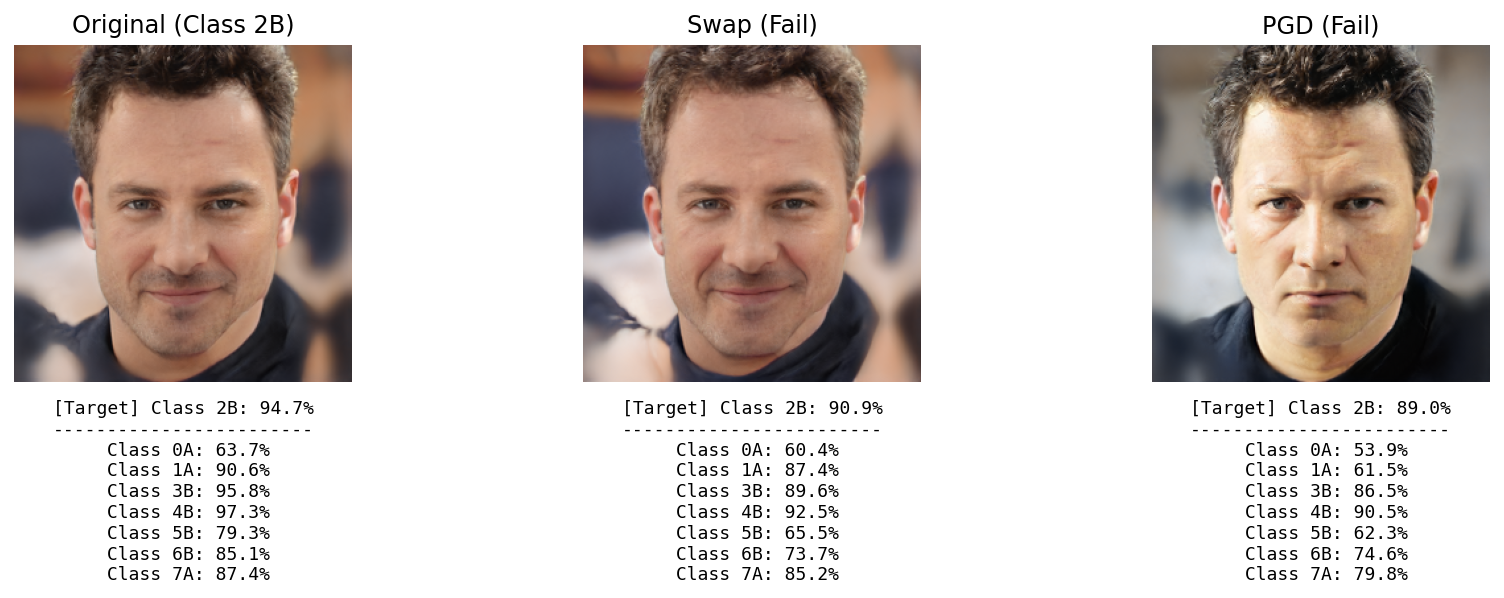

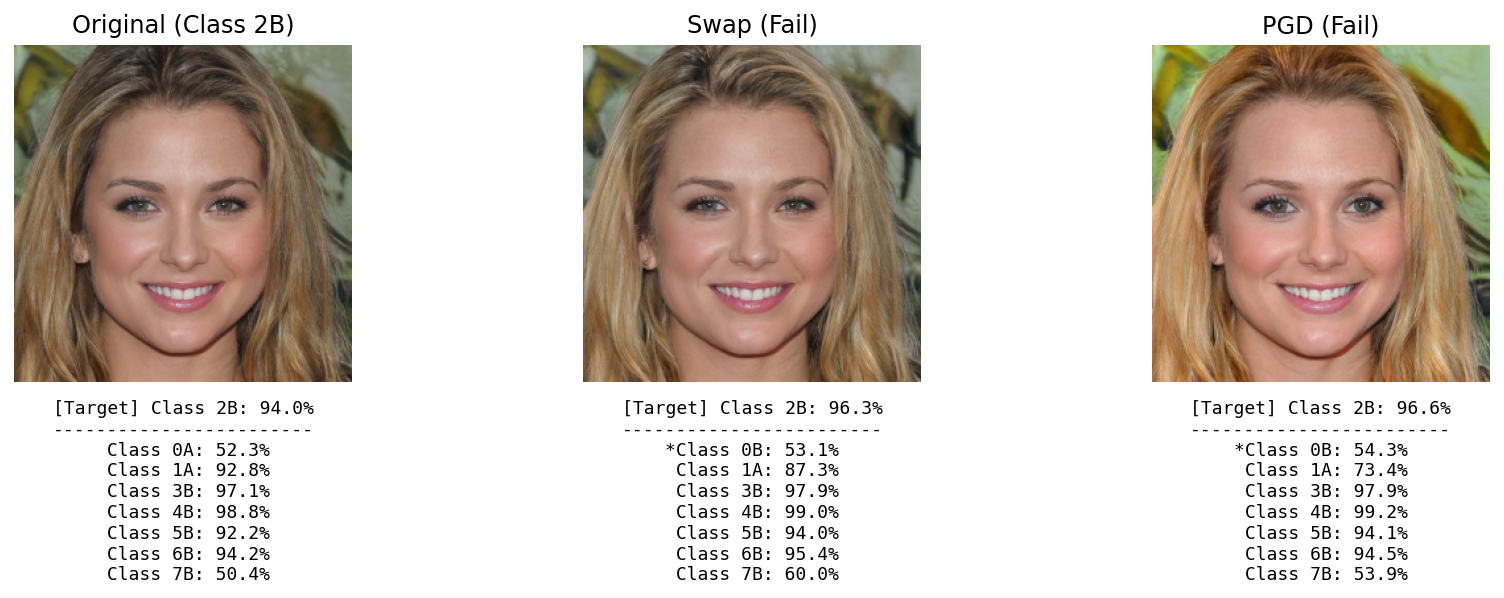

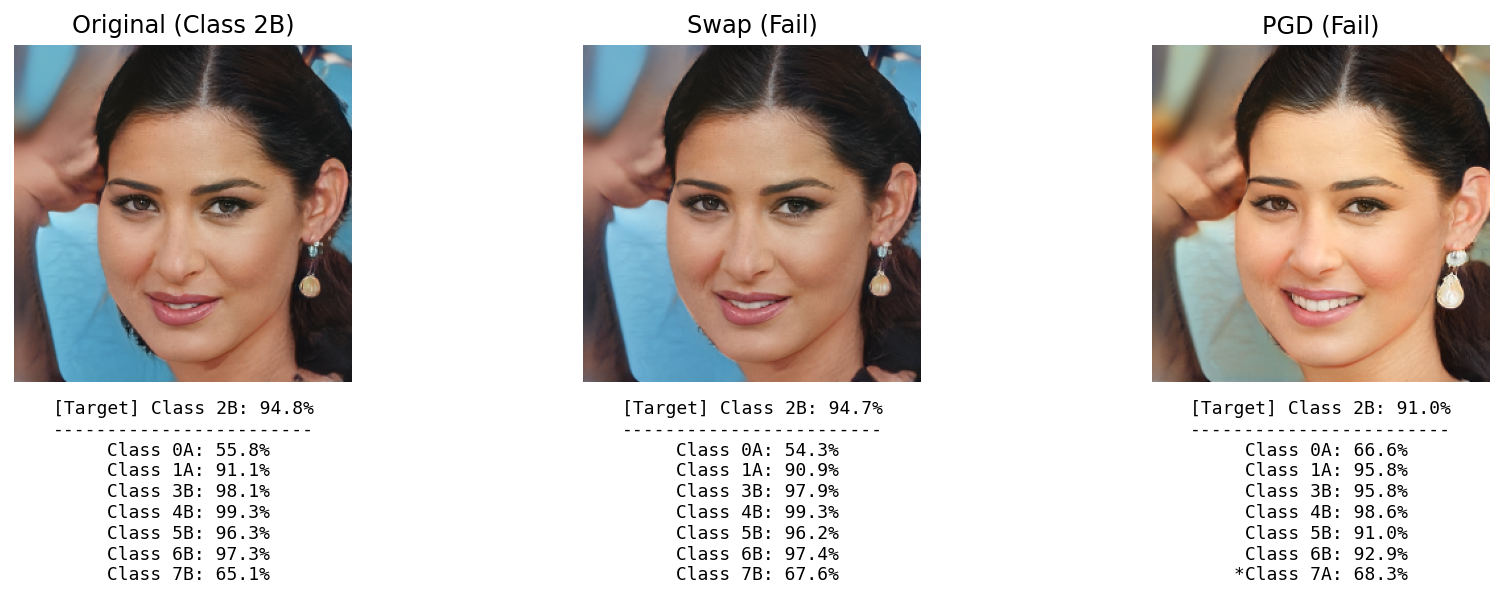

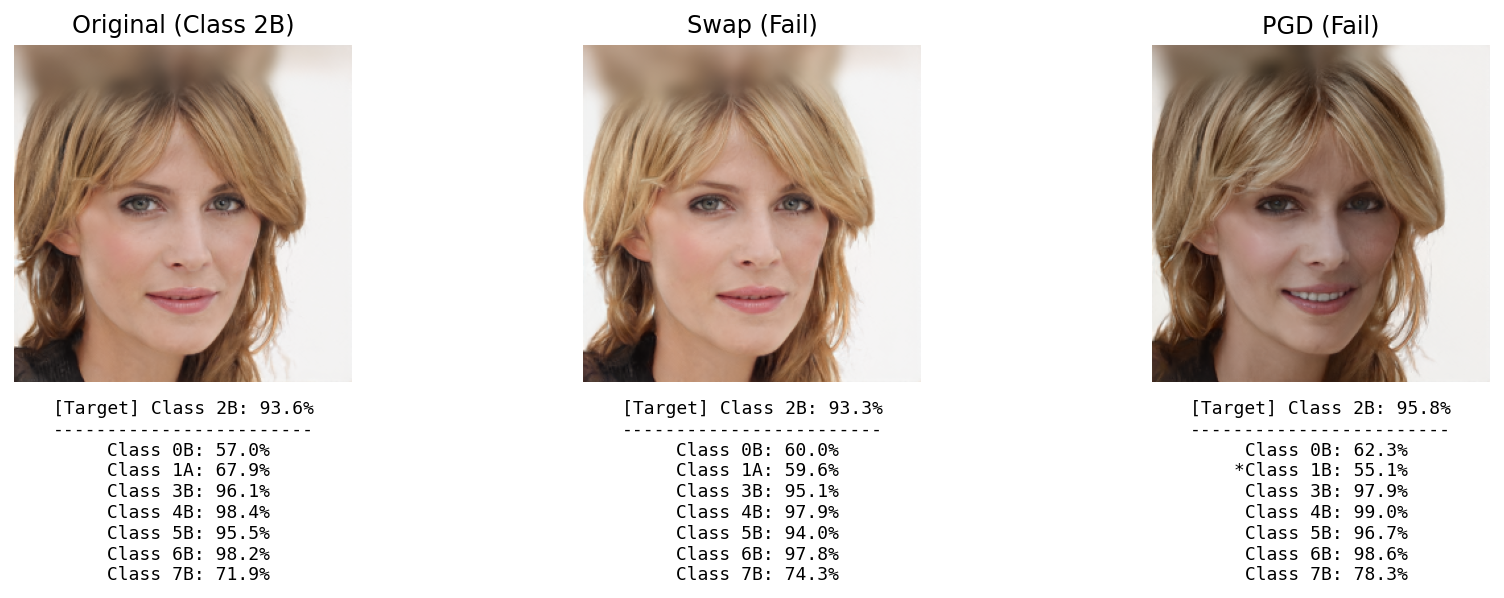

Total Intervention Success Rates:
Swap: 0.00%
PGD: 0.00%


In [16]:
target_concept = 'Class 2'
concept_value = 0
num_samples = 4
threshold = 0.6  # relaxed concept

random_entanglement_examples(
    target_concept, concept_value, num_samples,
    threshold=threshold
)

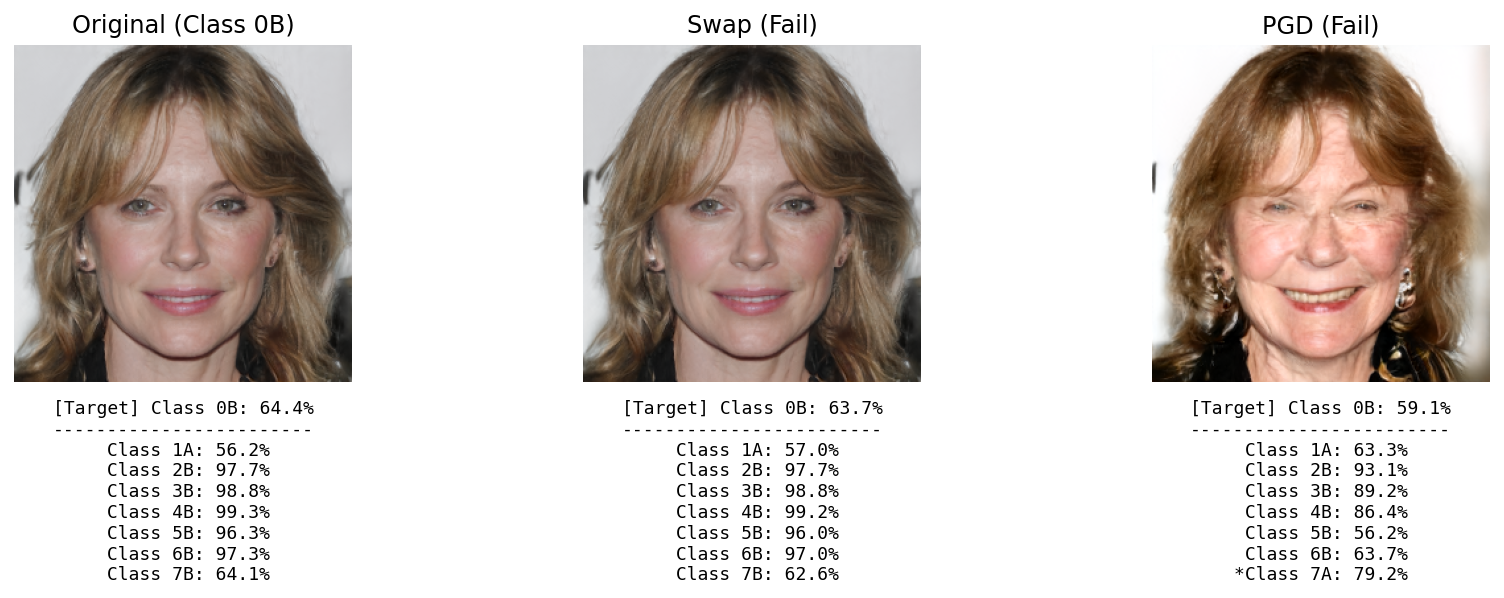

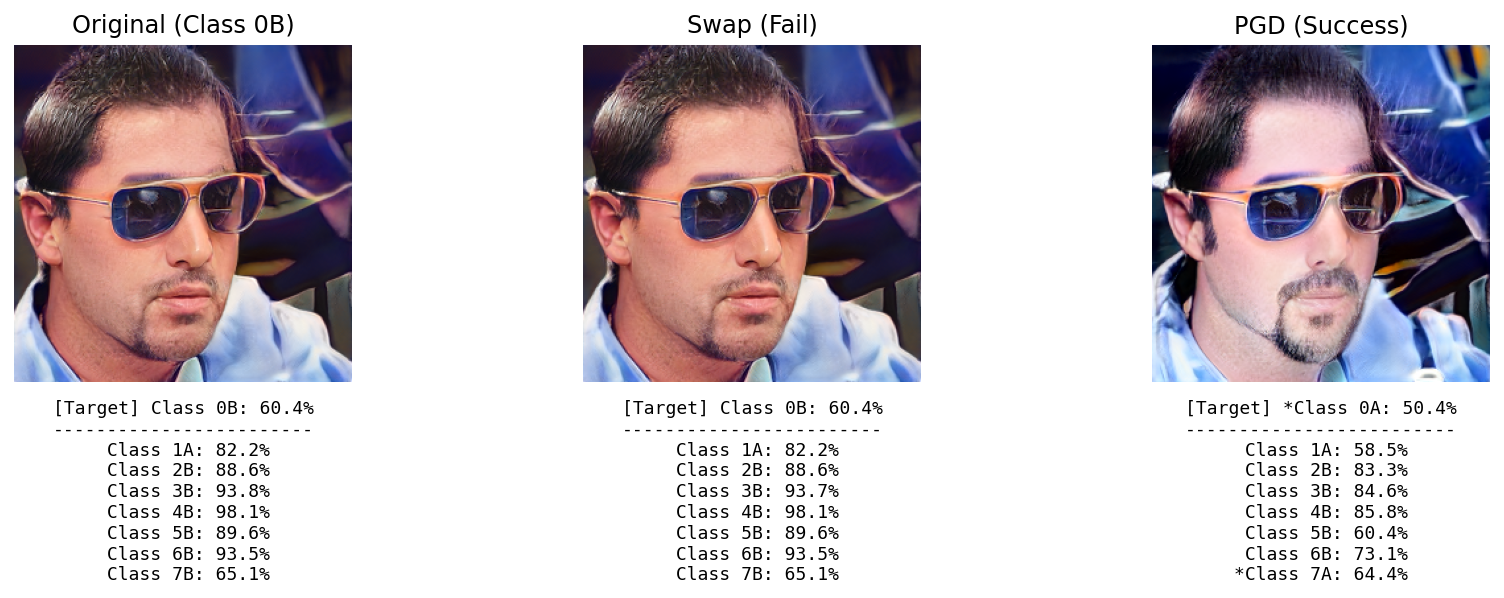

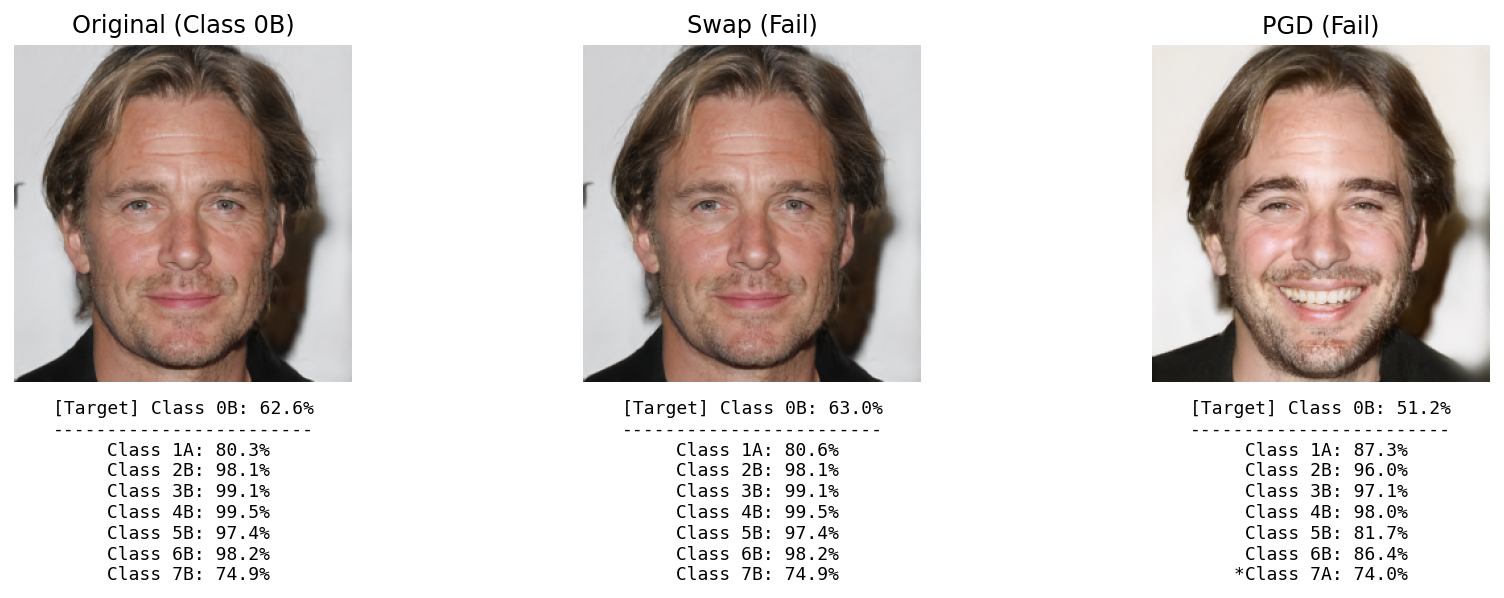

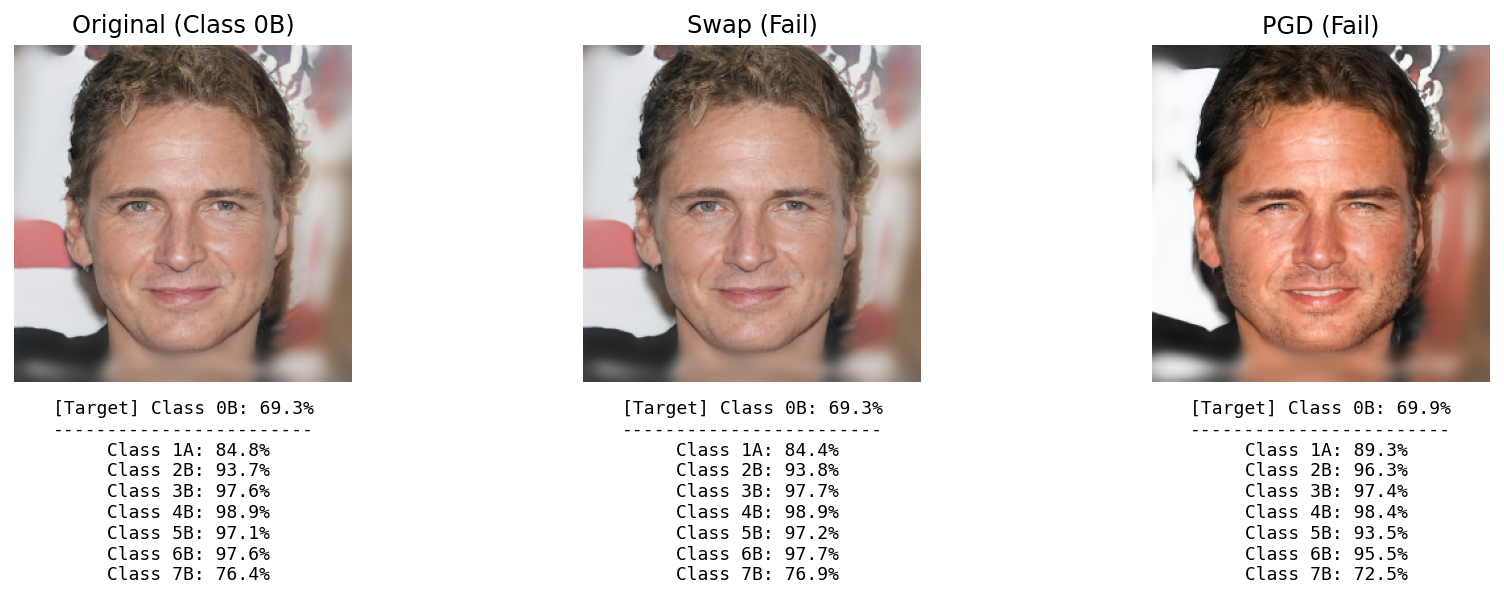

Total Intervention Success Rates:
Swap: 0.00%
PGD: 25.00%


In [17]:
target_concept = 'Class 0'
concept_value = 0
num_samples = 4
threshold = 0.6

random_entanglement_examples(
    target_concept, concept_value, num_samples,
    threshold=threshold
)

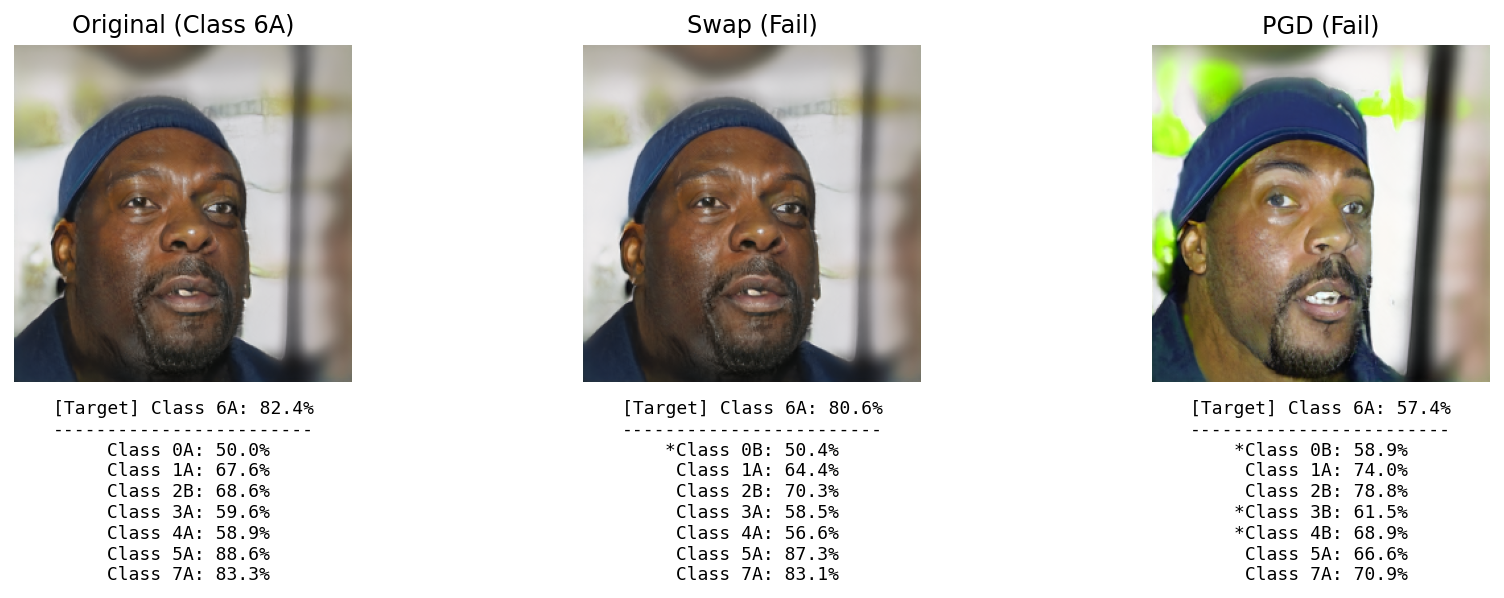

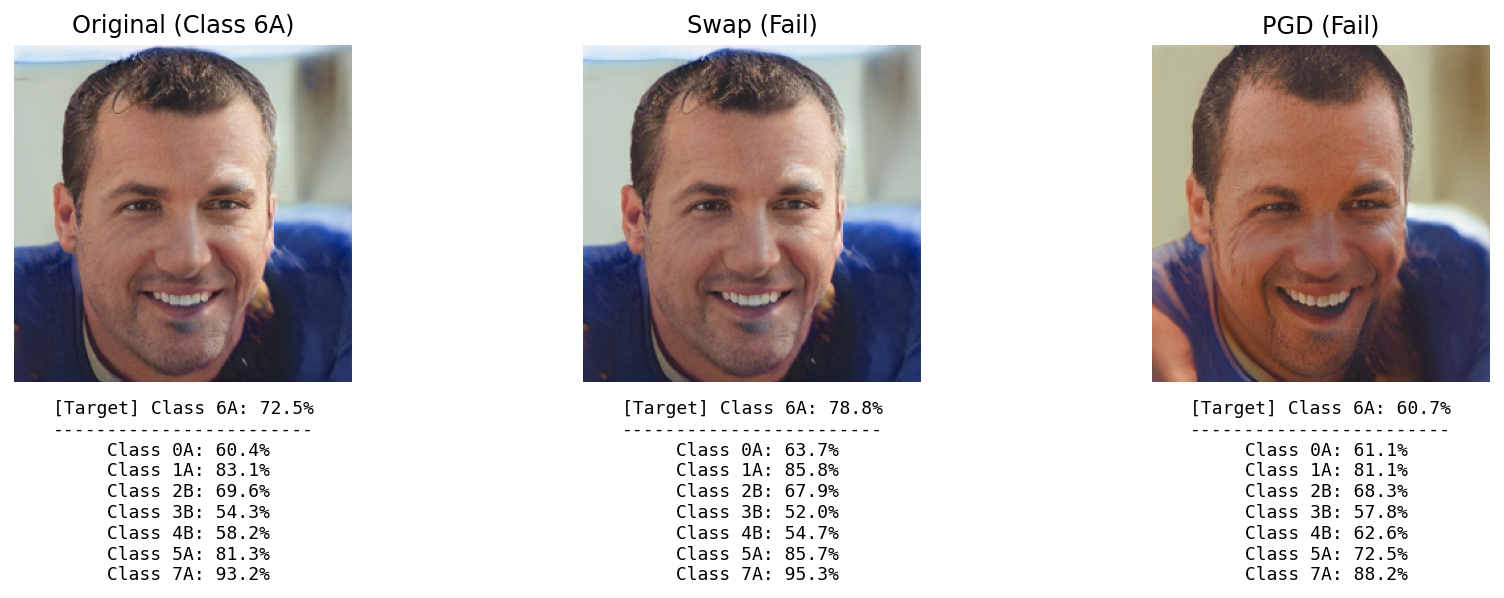

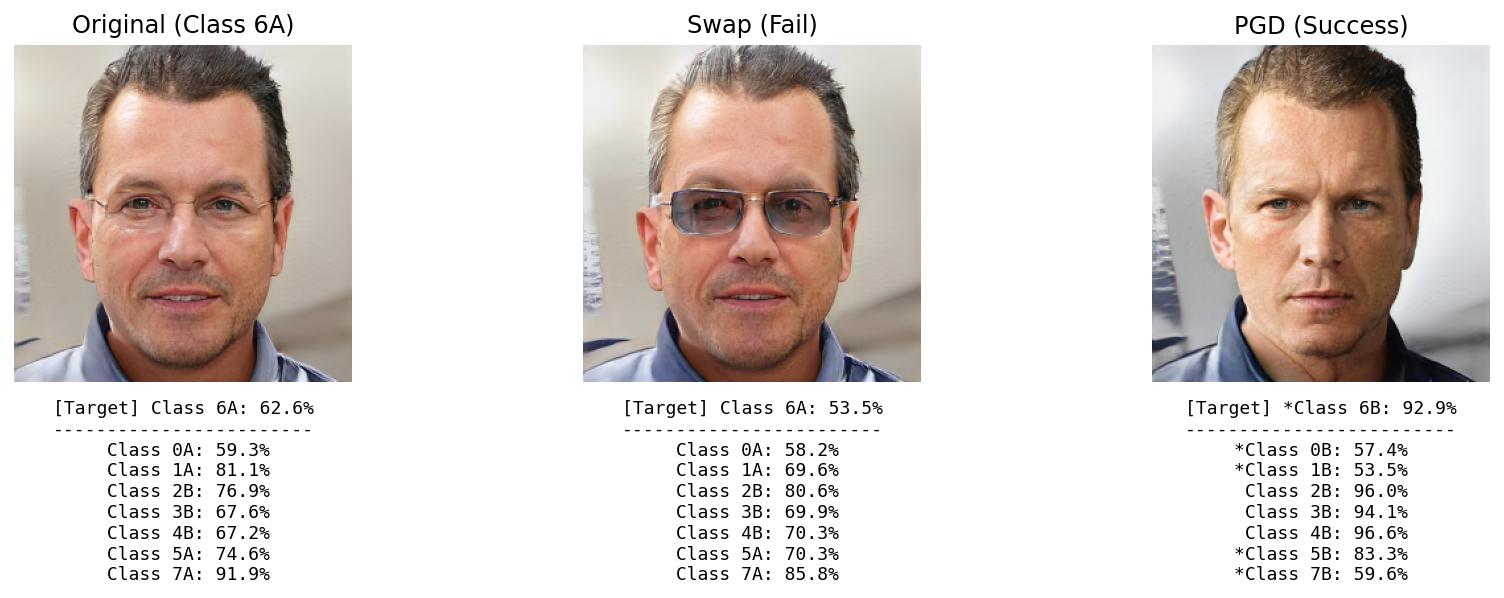

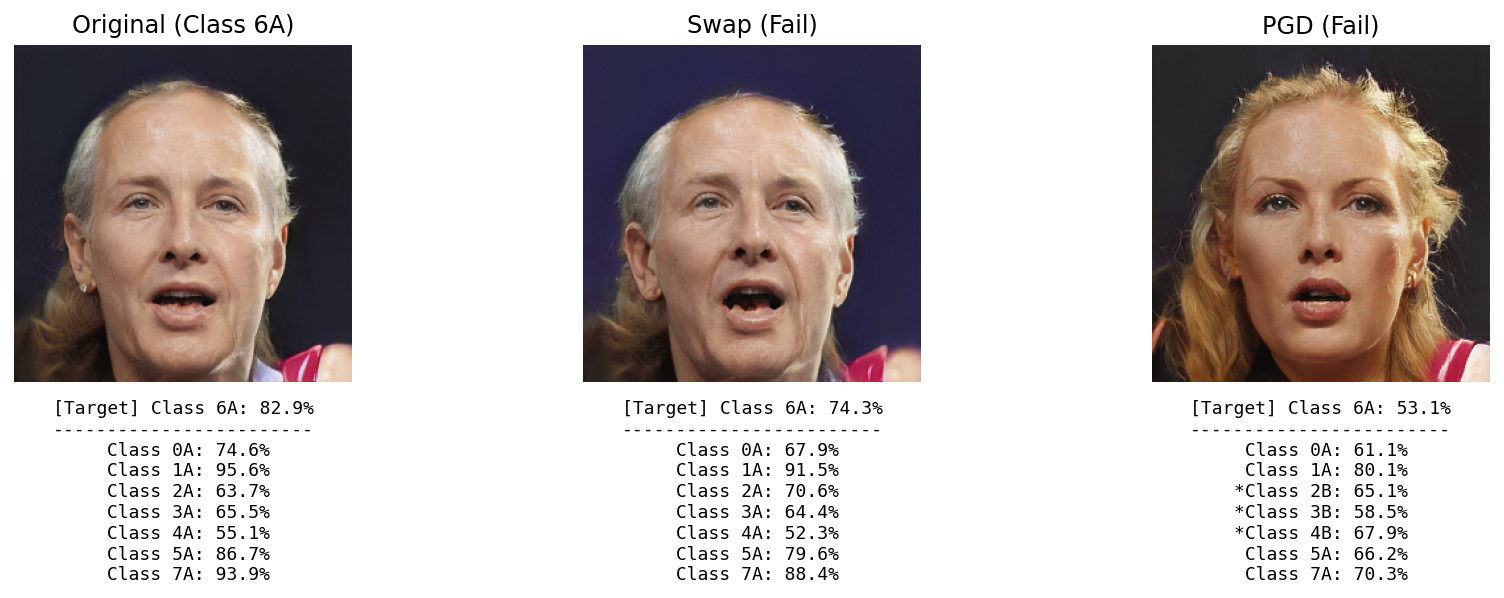

Total Intervention Success Rates:
Swap: 0.00%
PGD: 25.00%


In [18]:
target_concept = 'Class 6'
concept_value = 1
num_samples = 4
threshold = 0.6

random_entanglement_examples(
    target_concept, concept_value, num_samples,
    threshold=threshold
)

### Quantification

In [12]:
def fill_matrix(original_preds, intervened_preds, matrix, target_idx):
    for pred_o, pred_i in zip(original_preds, intervened_preds):
        for concept in pred_o:
            concept_idx = conc_clsf_classes.index(concept)
            matrix[target_idx][concept_idx] += (pred_o[concept][0] != pred_i[concept][0])

In [13]:
def entanglement_quantify(num_samples, threshold=0.9, combine=False):
    # concept flipping matrix
    matrix_size = (len(conc_clsf_classes), len(conc_clsf_classes))
    swap_flip_rates = [np.zeros(matrix_size), np.zeros(matrix_size)]  # 0, 1
    pgd_flip_rates = [np.zeros(matrix_size), np.zeros(matrix_size)]
    total_samples = 0

    pbar = tqdm(total=matrix_size[0] * 2)
    for target_concept in conc_clsf_classes:
        concept_change = conc_clsf_classes.index(target_concept)
        start, end = get_concept_index(model, concept_change)

        for concept_value in [0, 1]:  # 0: 1->0 ; 1: 0->1
            try:
                # generate images
                orig_imgs, orig_latent, orig_preds = generate_confident_images(
                    model, target_concept, concept_value,
                    num_images=num_samples, threshold=threshold
                )

                # CB-AE bottleneck swap
                swap_latent = swap_intervention(model, orig_latent.clone(), start, end)
                swap_imgs = model.gen.synthesis(
                   swap_latent, noise_mode='const'
                ).clamp(-1,1).mul(0.5).add_(0.5)
                swap_preds = classify_images_all_concepts(swap_imgs)
                fill_matrix(orig_preds, swap_preds, swap_flip_rates[concept_value], concept_change)

                # PGD optimization-based intervention
                pgd_latent = opt_int(
                    model, orig_latent, concept_change, concept_value,
                    num_iters=optint_iters, eps=optint_eps, device=device 
                )
                pgd_imgs = model.gen.synthesis(
                   pgd_latent, noise_mode='const'
                ).clamp(-1,1).mul(0.5).add_(0.5)
                pgd_preds = classify_images_all_concepts(pgd_imgs)
                fill_matrix(orig_preds, pgd_preds, pgd_flip_rates[concept_value], concept_change)

                # clear cache
                total_samples += orig_imgs.shape[0]
                del orig_imgs, orig_latent, swap_latent, swap_imgs, pgd_latent, pgd_imgs
                torch.cuda.empty_cache()
                
            except RuntimeError:
                continue
            finally:
                pbar.update(1)              
    pbar.close()
    
    # normalize and save
    if combine:  # random: handle not enough images
        flip_rates = (
            swap_flip_rates[0] + swap_flip_rates[1] +
            pgd_flip_rates[0] + pgd_flip_rates[1]
        )
        flip_rates = flip_rates / total_samples

        np.save('random_flip_rates.npy', flip_rates)
        return np.load('random_flip_rates.npy')
    else:
        swap_flip_rates[0] = swap_flip_rates[0] / num_samples
        swap_flip_rates[1] = swap_flip_rates[1] / num_samples
        pgd_flip_rates[0] = pgd_flip_rates[0] / num_samples
        pgd_flip_rates[1] = pgd_flip_rates[1] / num_samples

        np.savez(
            'flip_rates.npz',
            swap_0=swap_flip_rates[0], swap_1=swap_flip_rates[1],
            pgd_0=pgd_flip_rates[0], pgd_1=pgd_flip_rates[1]
        )
        return np.load('flip_rates.npz')

In [14]:
def plot_flip_rates(matrix, concepts, method=None, concept_value=None, fig=None, ax=None):
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        title = 'Random Concept Entanglement Flip Rates'
    else:
        title_on_off = r"On $\rightarrow$ Off" if concept_value == 0 else r"Off $\rightarrow$ On"
        title = f"Concept Entanglement Flip Rates: {method}, {title_on_off}"
    
    im = ax.imshow(matrix, cmap='Reds', vmin=0, vmax=1)

    # overlay text
    for i in range(len(concepts)):
        for j in range(len(concepts)):
            value = matrix[i, j]
            text_color = 'white' if value > 0.5 else 'black'
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_color)

    # axes
    ax.set_xticks(np.arange(len(concepts)))
    ax.set_yticks(np.arange(len(concepts)))
    ax.set_xticklabels(concepts, rotation=45, ha='right')
    ax.set_yticklabels(concepts)
    ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)

    # colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Concept Flip Rate', rotation=270, labelpad=15)

    # axis title
    ax.set_xlabel("Co-change Concept")
    ax.set_ylabel("Target Concept")
    ax.set_title(title)
    fig.tight_layout()

  0%|                                                                                            | 0/16 [00:00<?, ?it/s]

Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.


100%|███████████████████████████████████████████████████████████████████████████████████| 16/16 [01:35<00:00,  6.00s/it]


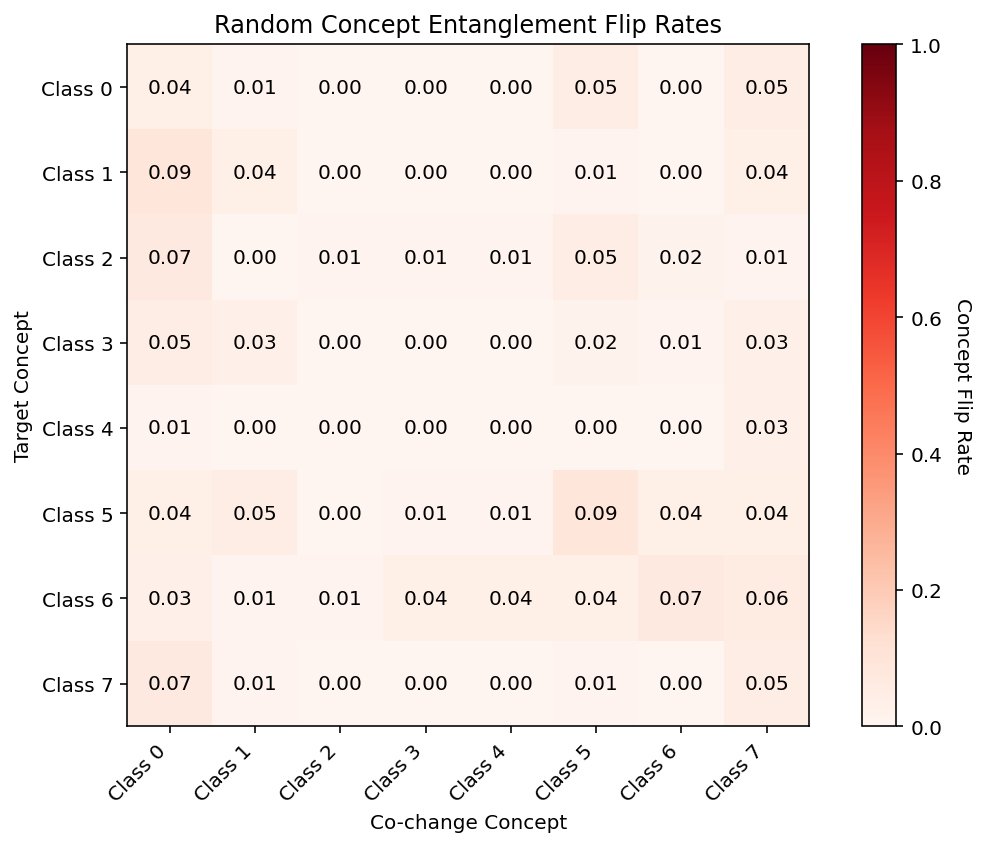

In [15]:
num_samples = 8
threshold = 0.55
flip_rate_matrix = entanglement_quantify(num_samples, threshold=threshold, combine=True)
plot_flip_rates(flip_rate_matrix, conc_clsf_classes)